# Prédiction des Arrêts d'Engins Miniers

Ce notebook couvre les étapes de préparation des données, d'analyse exploratoire (Data Visualization), et de modélisation avec XGBoost.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

## 1. Chargement et Nettoyage des Données

In [3]:
# Lecture du fichier (on ignore les 8 premières lignes de métadonnées)
df = pd.read_excel('Arrêts engins modifié_2025.xlsx', skiprows=8)

# Standardisation des noms de colonnes
df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]

if 'durée' in df.columns:
    df.rename(columns={'durée': 'duree'}, inplace=True)
if 'début_arrêt' in df.columns:
    df.rename(columns={'début_arrêt': 'debut_arret'}, inplace=True)
if 'fin_arrêt' in df.columns:
    df.rename(columns={'fin_arrêt': 'fin_arret'}, inplace=True)
if 'catégorie' in df.columns:
    df.rename(columns={'catégorie': 'categorie'}, inplace=True)

df.head()

,engin,debut_arret,fin_arret,type,categorie,description_arrêt,duree
0,7500 M/2,2025-12-31 19:03:22,2025-12-31 23:00:00,NaN,NaN,NaN,0 days 03:56:38
1,PH 1,2025-12-31 21:57:51,2025-12-31 22:28:41,NaN,NaN,NaN,0 days 00:30:50
2,7500 M/2,2025-12-31 09:00:18,2025-12-31 19:00:59,Arrêt non justifié,Micro-arrêts,En service,0 days 10:00:41
3,PH 1,2025-12-31 14:27:09,2025-12-31 14:47:01,NaN,NaN,NaN,0 days 00:19:52
4,PH 1,2025-12-31 12:45:27,2025-12-31 13:32:54,PANNE - ATELIER DRAGLINE,MATERIEL,Support de balancier fissuré,0 days 00:47:27


## 2. Feature Engineering

In [4]:
# Conversion des dates
df['debut_arret'] = pd.to_datetime(df['debut_arret'], errors='coerce')
df['fin_arret'] = pd.to_datetime(df['fin_arret'], errors='coerce')
df = df.dropna(subset=['debut_arret'])

# Calcul de la durée en minutes
def parse_duration(d):
    if pd.isna(d): return 0
    if isinstance(d, str):
        parts = d.split(':')
        if len(parts) == 3:
            return int(parts[0]) * 60 + int(parts[1]) + int(parts[2]) / 60.0
    elif isinstance(d, pd.Timedelta):
        return d.total_seconds() / 60.0
    return 0

if 'duree' in df.columns:
    df['duree_minutes'] = df['duree'].apply(parse_duration)
else:
    df['duree_minutes'] = (df['fin_arret'] - df['debut_arret']).dt.total_seconds() / 60.0

df = df[df['duree_minutes'] >= 0]

# Valeurs manquantes
df['type'] = df['type'].fillna('Inconnu')
df['categorie'] = df['categorie'].fillna('Inconnu')

# Features temporelles
df['heure_jour'] = df['debut_arret'].dt.hour
df['jour_semaine'] = df['debut_arret'].dt.dayofweek
df['est_weekend'] = df['jour_semaine'].isin([5, 6]).astype(int)

def get_quart(h):
    if 6 <= h < 14: return 'Matin'
    elif 14 <= h < 22: return 'Apres-midi'
    else: return 'Nuit'
df['quart_travail'] = df['heure_jour'].apply(get_quart)

# Features historiques
df = df.sort_values(by=['engin', 'debut_arret'])

# Temps écoulé depuis le dernier arrêt (TBF)
df['temps_depuis_dernier_arret'] = df.groupby('engin')['debut_arret'].diff().dt.total_seconds() / 3600.0
df['temps_depuis_dernier_arret'] = df['temps_depuis_dernier_arret'].fillna(0)

# Moyenne mobile des durées précédentes
df['moyenne_duree_mobile_engin'] = df.groupby('engin')['duree_minutes'].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))
df['moyenne_duree_mobile_engin'] = df['moyenne_duree_mobile_engin'].fillna(df['duree_minutes'].mean())

# Tri chronologique final
df = df.sort_values('debut_arret').reset_index(drop=True)


## 3. Data Visualization

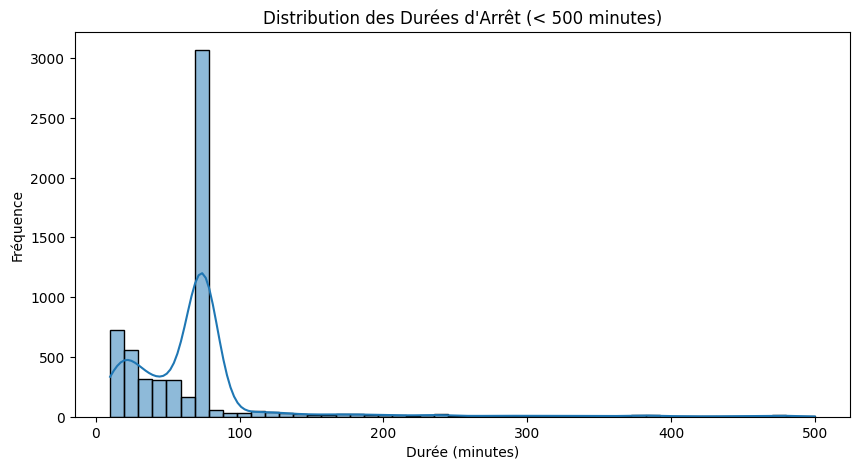

In [5]:
# Distribution de la durée des arrêts (en minutes)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['duree_minutes'] < 500]['duree_minutes'], bins=50, kde=True)
plt.title('Distribution des Durées d\'Arrêt (< 500 minutes)')
plt.xlabel('Durée (minutes)')
plt.ylabel('Fréquence')
plt.show()

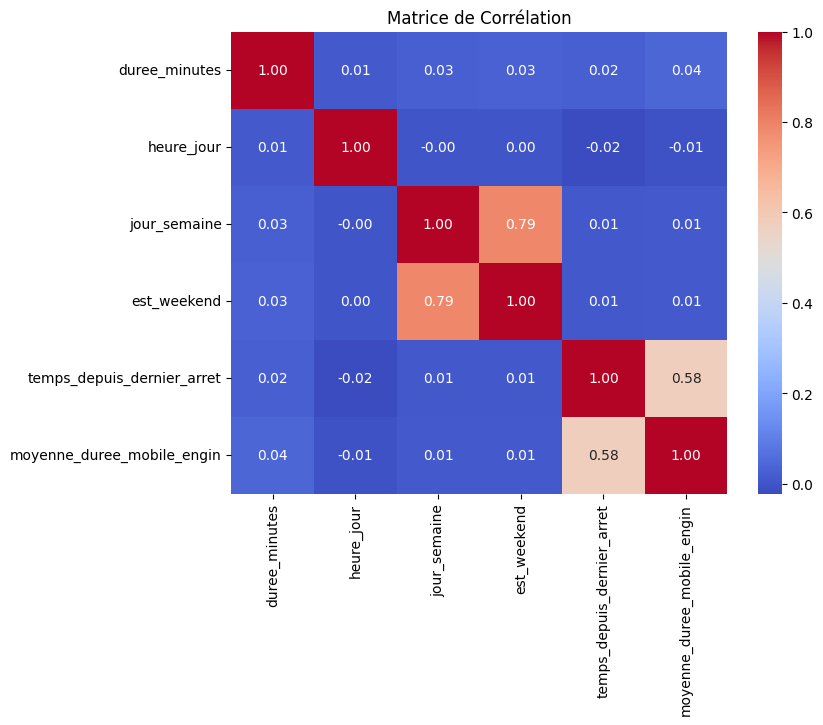

In [6]:
# Heatmap des corrélations numériques
numeric_cols = ['duree_minutes', 'heure_jour', 'jour_semaine', 'est_weekend', 'temps_depuis_dernier_arret', 'moyenne_duree_mobile_engin']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation')
plt.show()

## 4. Préparation pour la Modélisation

In [7]:
# Encodage des variables catégorielles
cat_cols = ['engin', 'type', 'categorie', 'quart_travail']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

features = ['heure_jour', 'jour_semaine', 'est_weekend', 'engin', 'type', 'categorie', 'quart_travail', 'temps_depuis_dernier_arret', 'moyenne_duree_mobile_engin']

X = df[features]
y = df['duree_minutes']

# Time Series Split (80% train, 20% test)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Train set: 4983 samples
Test set: 1246 samples


## 5. Modélisation et Métriques avec XGBoost

In [8]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, xgb_pred)
rmse = root_mean_squared_error(y_test, xgb_pred)

print(f"XGBoost MAE: {mae:.2f} minutes")
print(f"XGBoost RMSE: {rmse:.2f} minutes")

XGBoost MAE: 200.42 minutes
XGBoost RMSE: 2362.45 minutes


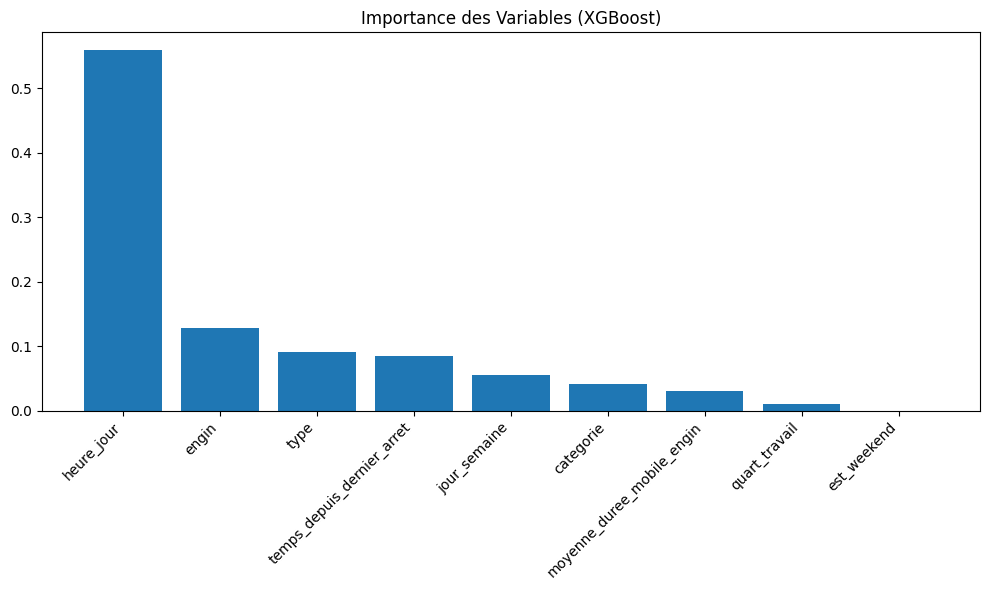

In [9]:
# Feature Importance
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Importance des Variables (XGBoost)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()